In [1]:
from math import *
import sys
import time

import numpy as np
from numpy.random import seed
from numpy.random import shuffle

import matplotlib.pyplot as plt

from scipy import signal
from scipy.stats import norm
from scipy.io.wavfile import read
from scipy.io import loadmat
from scipy.optimize import minimize_scalar

sys.path.append('..')
import Pylos_toolkit as PyT

scaling = 10 ** (168./20)

# Notebook to create PSDs for a given segment length
- $0 < f < 72$ kHz
- unscaled

In [2]:
# use the pylos toolkit
t, y, sampling_rate, filename = PyT.load_Pylos_data(filename='../201650198.180131085932.wav', trace_length_s=1000)

Sampling rate:          144000 Hz
Length of time series:  120 minutes
Length of output time series:  1000 seconds


In [3]:
# Take a smaller timetrace for the fits to limit runtime
trace_FFT_start = 0.  # [s]
trace_FFT_end   = 1000. # [s]

i_FFT_start = int(trace_FFT_start * sampling_rate)
i_FFT_end   = int(trace_FFT_end * sampling_rate)

t_FFT = np.arange((i_FFT_end - i_FFT_start),dtype=float)
t_FFT /= sampling_rate

y_FFT = np.array(y[i_FFT_start : i_FFT_end],dtype=float)

# Processing
# y_FFT -= np.mean(y_FFT) # Remove DC offset

In [ ]:
def export_PSDs(y, nperseg):

    sampling_rate = 144e3

    if nperseg > len(y):
        assert False, "nperseg is larger than the length of the signal!"

    freqstring  = f"PSD_exports/Pylos_freq_{nperseg}.bin"
    PSDstring   = f"PSD_exports/Pylos_PSD_{nperseg}.bin"
    print("outfiles: ", freqstring, PSDstring)

    SS = 1

    SS0factor       = PyT.correction_factor_Welch(SS)
    freqs_ref       = np.linspace(1, 72000, 1000)
    PSD_ss0         = PyT.Knudsen_curve(seastate=SS, frequency=freqs_ref)

    freqs, m_dat    = signal.welch(y, sampling_rate, nperseg=nperseg, scaling= 'density',window='hann')
    p_plot          = 10 * np.log10(m_dat * 1e12 / (SS0factor * SS0factor))

    plt.figure(figsize=(6,2.5))
    plt.plot(freqs, p_plot, label='Scaled Pylos data')
    plt.plot(freqs_ref, PSD_ss0, label=f'Knudsen curve (SS{SS})')
    plt.title(f'FFT Amplitude Spectrum - DC removed, nperseg={nperseg}')
    plt.xlabel('Frequency [Hz]')
    plt.ylabel('dB re 1 $\mu$Pa$^2$/Hz')
    plt.axvline(1e3, color='k', linestyle='--')
    plt.axvline(25e3, color='k', linestyle='--')
    # plt.set_xlim([0, 72e3])
    plt.xscale('log')
    plt.legend()
    plt.ylabel('dB re 1 $\mu$Pa$^2$/Hz')
    plt.grid()
    plt.tight_layout()
    plt.show()

    m_dat.tofile(PSDstring)
    freqs.tofile(freqstring)


Exporting PSDs for nperseg = 1024, length = 0.0071111111111111115 s
outfiles:  Pylos_freq_1024.bin Pylos_PSD_1024.bin


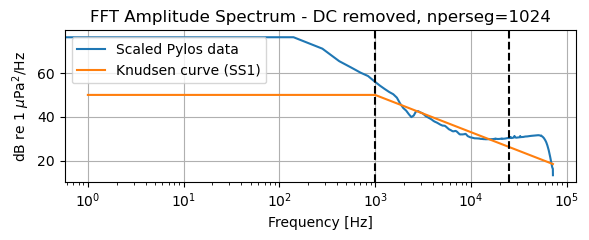

Exporting PSDs for nperseg = 2048, length = 0.014222222222222223 s
outfiles:  Pylos_freq_2048.bin Pylos_PSD_2048.bin


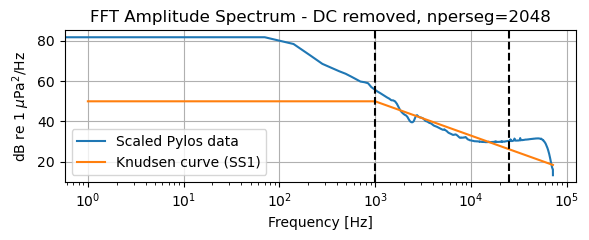

Exporting PSDs for nperseg = 4096, length = 0.028444444444444446 s
outfiles:  Pylos_freq_4096.bin Pylos_PSD_4096.bin


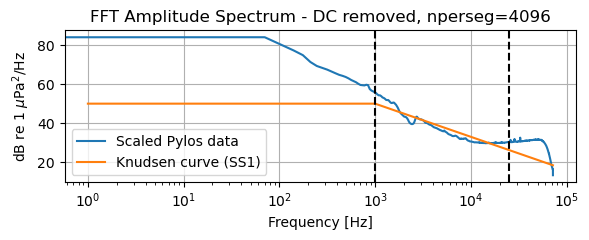

Exporting PSDs for nperseg = 8192, length = 0.05688888888888889 s
outfiles:  Pylos_freq_8192.bin Pylos_PSD_8192.bin


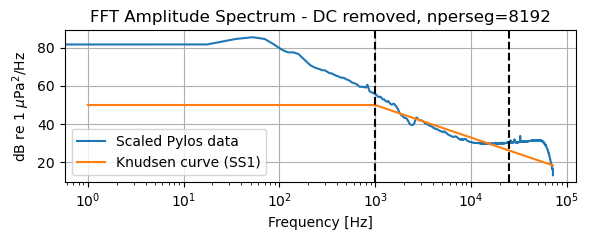

Exporting PSDs for nperseg = 16384, length = 0.11377777777777778 s
outfiles:  Pylos_freq_16384.bin Pylos_PSD_16384.bin


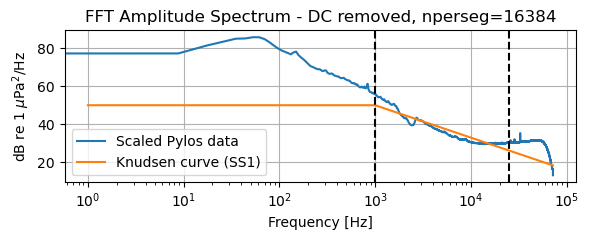

Exporting PSDs for nperseg = 32768, length = 0.22755555555555557 s
outfiles:  Pylos_freq_32768.bin Pylos_PSD_32768.bin


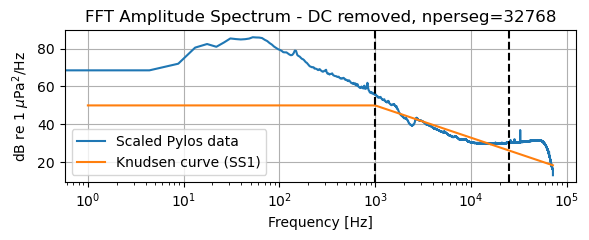

Exporting PSDs for nperseg = 65536, length = 0.45511111111111113 s
outfiles:  Pylos_freq_65536.bin Pylos_PSD_65536.bin


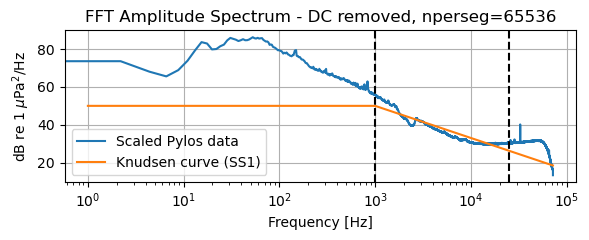

Exporting PSDs for nperseg = 131072, length = 0.9102222222222223 s
outfiles:  Pylos_freq_131072.bin Pylos_PSD_131072.bin


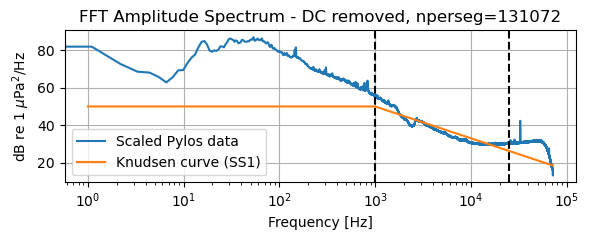

Exporting PSDs for nperseg = 262144, length = 1.8204444444444445 s
outfiles:  Pylos_freq_262144.bin Pylos_PSD_262144.bin


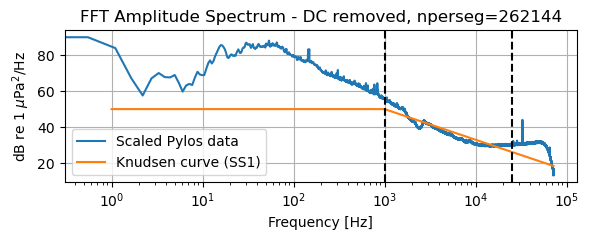

Exporting PSDs for nperseg = 524288, length = 3.640888888888889 s
outfiles:  Pylos_freq_524288.bin Pylos_PSD_524288.bin


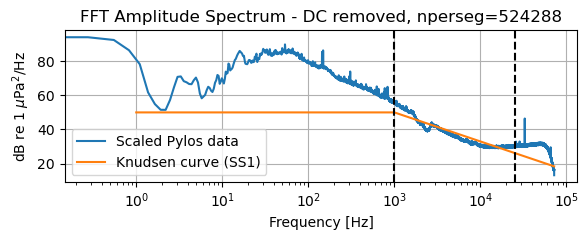

Exporting PSDs for nperseg = 1048576, length = 7.281777777777778 s
outfiles:  Pylos_freq_1048576.bin Pylos_PSD_1048576.bin


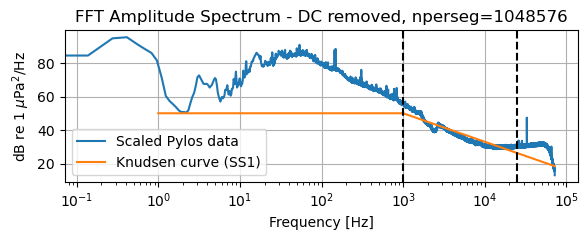

In [7]:
exps            = np.linspace(10, 20, 11,dtype=int)
nperseg_list    = 2 ** exps

for nperseg in nperseg_list:
    print(f"Exporting PSDs for nperseg = {nperseg}, length = {nperseg/sampling_rate} s")
    export_PSDs(y_FFT, nperseg)